In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, GroupKFold, GridSearchCV, learning_curve, validation_curve
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, f1_score
)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 150   # sharper inline previews (final figures still saved at dpi=300)

In [ ]:
# --- Option A: running in Google Colab -> upload the two files interactively ---
try:
    from google.colab import files
    import io
    print("Upload ecg_raw_data_2.csv and all_sensors_data_2.csv")
    uploaded = files.upload()
    ecg  = pd.read_csv(io.BytesIO(uploaded["ecg_raw_data_2.csv"]))
    summ = pd.read_csv(io.BytesIO(uploaded["all_sensors_data_2.csv"]))
except ModuleNotFoundError:
    # --- Option B: running locally / files already on disk ---
    ECG_PATH = "ecg_raw_data_2.csv"
    SUMMARY_PATH = "all_sensors_data_2.csv"
    ecg  = pd.read_csv(ECG_PATH)
    summ = pd.read_csv(SUMMARY_PATH)

# timestamps were written with pandas' isoformat(), which drops the microsecond
# field when it's exactly .000000 -> mixed precision, so parse with format='ISO8601'
ecg["timestamp"]  = pd.to_datetime(ecg["timestamp"],  format="ISO8601")
summ["timestamp"] = pd.to_datetime(summ["timestamp"], format="ISO8601")
ecg  = ecg.sort_values("timestamp").reset_index(drop=True)
summ = summ.sort_values("timestamp").reset_index(drop=True)

print("ECG raw waveform :", ecg.shape)
print("All-sensors 1 Hz :", summ.shape)
print("Session span     :", summ['timestamp'].min(), "->", summ['timestamp'].max())
summ.head()

Upload ecg_raw_data_2.csv and all_sensors_data_2.csv


Saving all_sensors_data_2.csv to all_sensors_data_2.csv
Saving ecg_raw_data_2.csv to ecg_raw_data_2.csv
ECG raw waveform : (91530, 5)
All-sensors 1 Hz : (2004, 12)
Session span     : 2026-09-14 05:47:27.315037 -> 2026-09-14 06:22:38.938301


,timestamp,device_millis,ppg_bpm,motion_magnitude,ecg_bpm,ecg_leads_off,skin_temp,fatigue_alert,ecg_hrv,marked,finger_detected,wifi_connected
0,2026-09-14 05:47:27.315037,4095,0,9.80,0,0,31.9,0,0.0,0,1,1
1,2026-09-14 05:47:28.321185,5101,0,11.05,165,0,31.9,0,0.0,0,1,1
2,2026-09-14 05:47:29.326819,6107,0,8.88,94,0,32.1,0,271.0,0,1,1
3,2026-09-14 05:47:30.333353,7113,0,9.42,94,0,32.1,0,271.0,0,1,1
4,2026-09-14 05:47:31.338978,8119,0,9.62,94,0,32.3,0,271.0,0,1,1


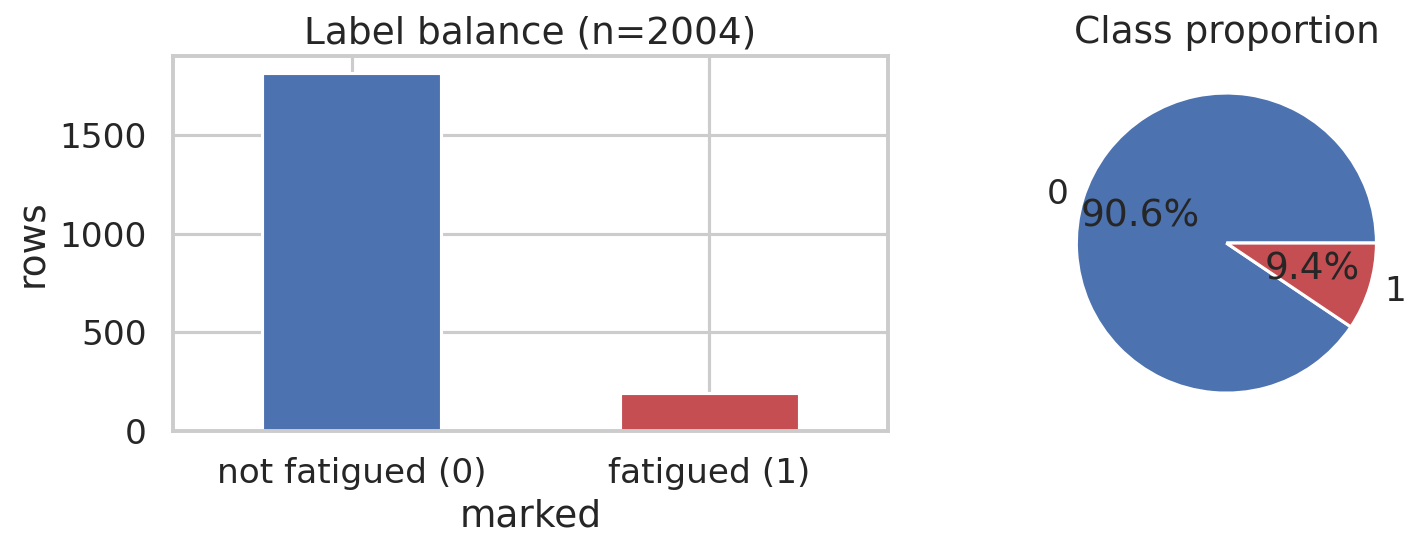

Positive (fatigued) rate: 9.4% of 1 Hz rows


In [ ]:
# --- 3a. class balance ---
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
summ["marked"].value_counts().sort_index().plot(
    kind="bar", ax=ax[0], color=["#4C72B0", "#C44E52"])
ax[0].set_xticklabels(["not fatigued (0)", "fatigued (1)"], rotation=0)
ax[0].set_title(f"Label balance (n={len(summ)})")
ax[0].set_ylabel("rows")

pct_positive = summ["marked"].mean() * 100
ax[1].pie([100 - pct_positive, pct_positive], labels=["0", "1"],
          autopct="%1.1f%%", colors=["#4C72B0", "#C44E52"])
ax[1].set_title("Class proportion")
plt.tight_layout()
plt.savefig("fig_class_balance.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Positive (fatigued) rate: {pct_positive:.1f}% of 1 Hz rows")

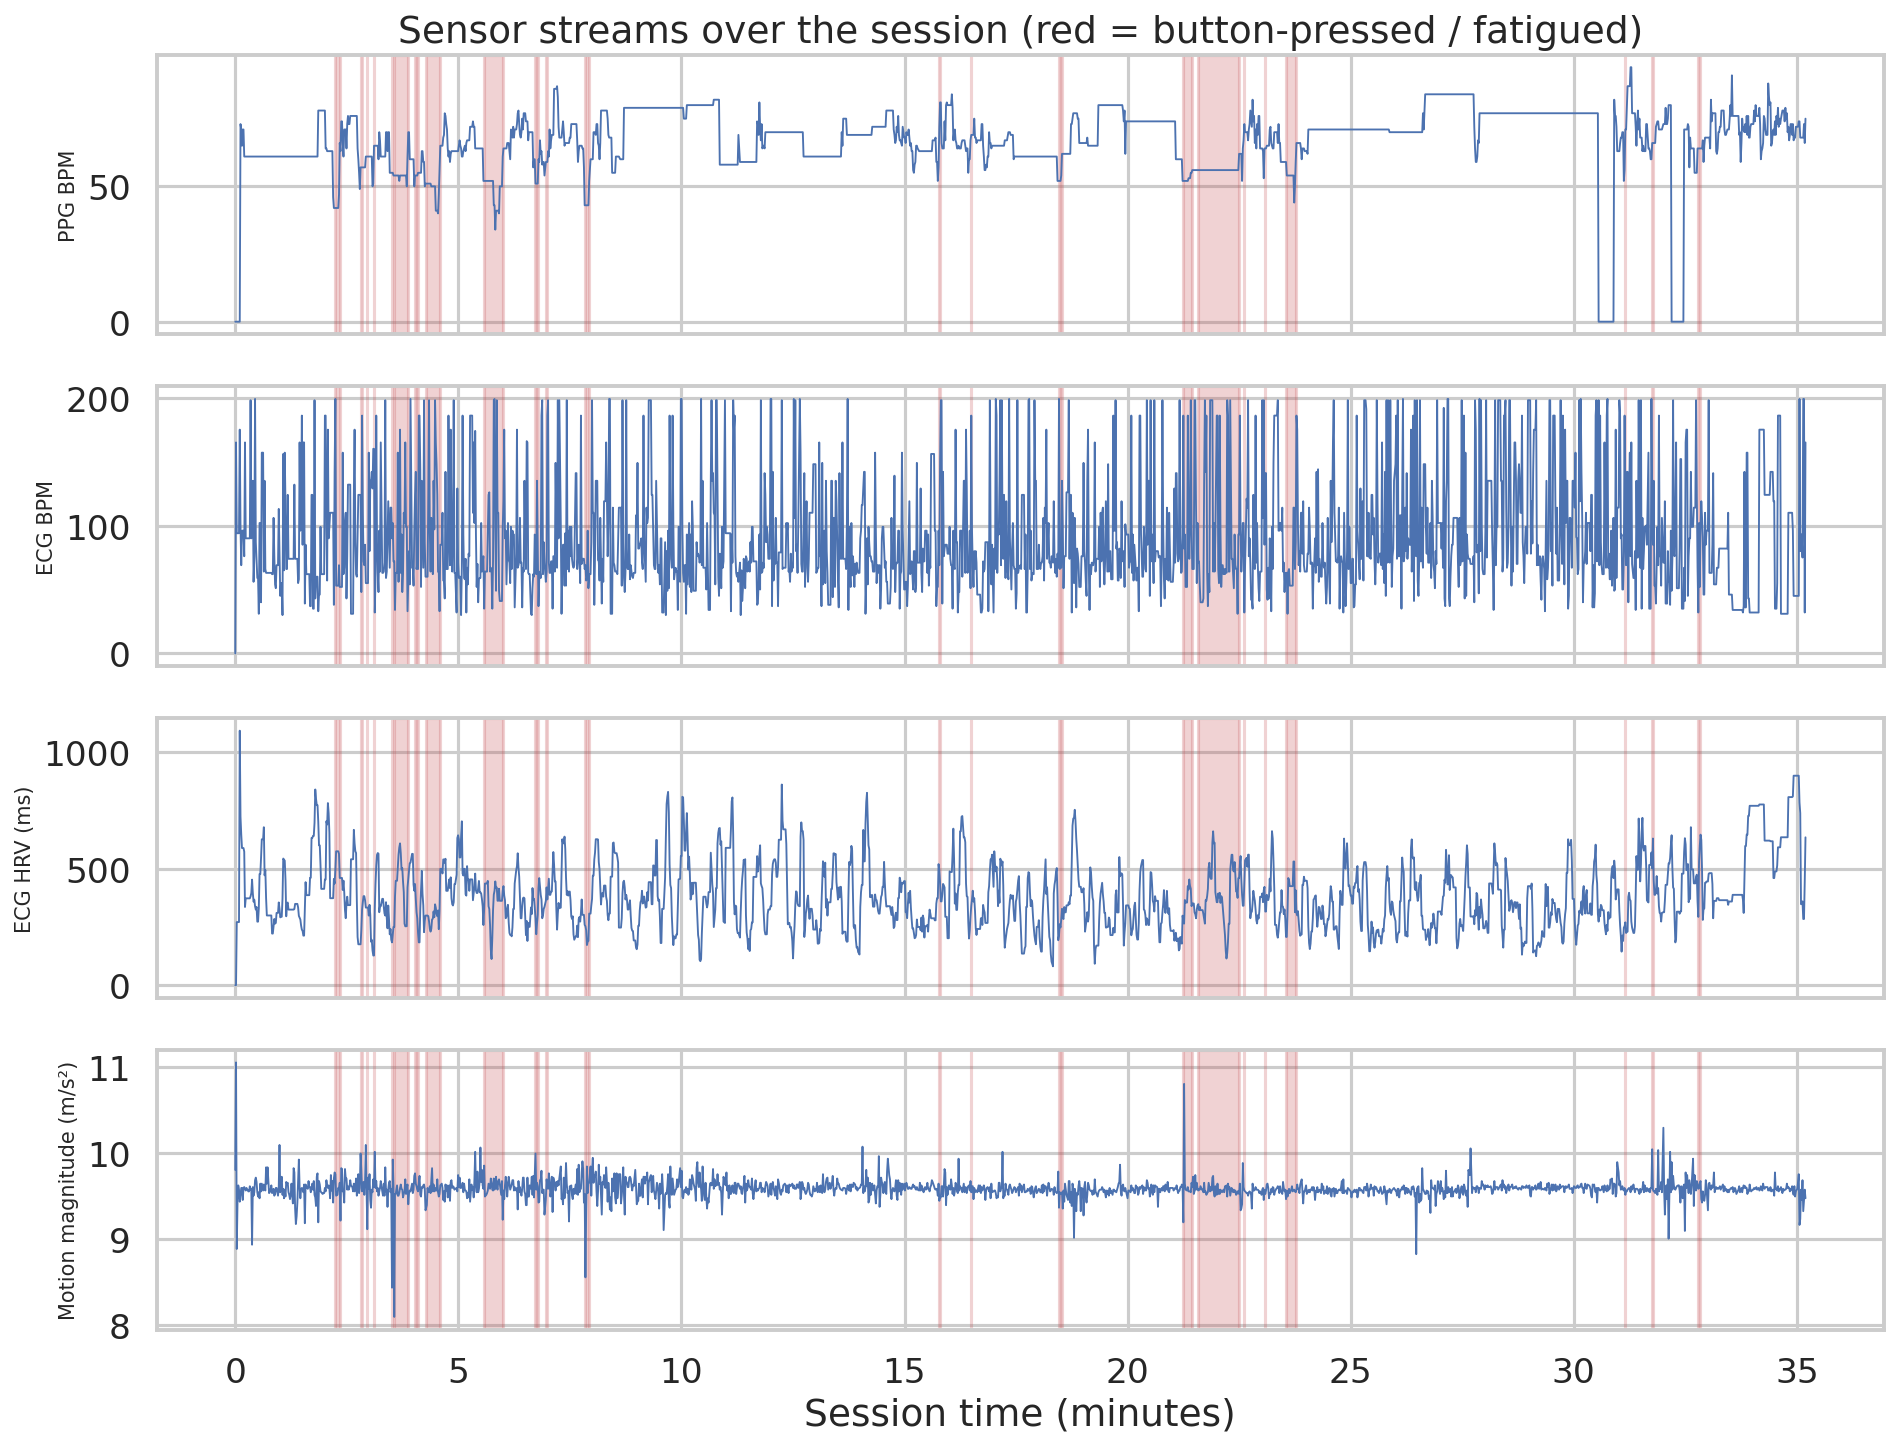

In [ ]:
# --- 3b. session timeline with button-press episodes shaded ---
t0 = summ["timestamp"].min()
summ["t_min"] = (summ["timestamp"] - t0).dt.total_seconds() / 60.0

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
signals = ["ppg_bpm", "ecg_bpm", "ecg_hrv", "motion_magnitude"]
labels  = ["PPG BPM", "ECG BPM", "ECG HRV (ms)", "Motion magnitude (m/s²)"]

for ax, col, lab in zip(axes, signals, labels):
    ax.plot(summ["t_min"], summ[col], lw=0.9, color="#4C72B0")
    ax.set_ylabel(lab, fontsize=10)
    # shade every marked=1 run
    marked = summ["marked"].values
    t = summ["t_min"].values
    in_run = False
    for i in range(len(marked)):
        if marked[i] == 1 and not in_run:
            start = t[i]; in_run = True
        if in_run and (i == len(marked) - 1 or marked[i + 1] == 0):
            ax.axvspan(start, t[i], color="#C44E52", alpha=0.25)
            in_run = False

axes[-1].set_xlabel("Session time (minutes)")
axes[0].set_title("Sensor streams over the session (red = button-pressed / fatigued)")
plt.tight_layout()
plt.savefig("fig_session_timeline.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
summ = summ.reset_index(drop=True)
summ["summary_idx"] = summ.index

matched = pd.merge_asof(ecg, summ[["timestamp", "summary_idx"]],
                         on="timestamp", direction="nearest")
matched["is_peak"] = (matched["peak_marker"] - matched["baseline"]) > 0

ecg_features = matched.groupby("summary_idx").agg(
    ecg_n_samples=("raw_ecg", "size"),
    ecg_mean=("raw_ecg", "mean"),
    ecg_std=("raw_ecg", "std"),
    ecg_min=("raw_ecg", "min"),
    ecg_max=("raw_ecg", "max"),
    ecg_peak_count=("is_peak", "sum"),
).reset_index()
ecg_features["ecg_range"] = ecg_features["ecg_max"] - ecg_features["ecg_min"]
ecg_features["ecg_std"] = ecg_features["ecg_std"].fillna(0)

df = summ.merge(ecg_features, on="summary_idx", how="left")
assert df["ecg_n_samples"].isna().sum() == 0, "some summary rows got no matching raw ECG samples"
print("Merged feature table:", df.shape)
df.head()

Merged feature table: (2004, 21)


,timestamp,device_millis,ppg_bpm,motion_magnitude,ecg_bpm,ecg_leads_off,skin_temp,fatigue_alert,ecg_hrv,marked,...,wifi_connected,t_min,summary_idx,ecg_n_samples,ecg_mean,ecg_std,ecg_min,ecg_max,ecg_peak_count,ecg_range
0,2026-09-14 05:47:27.315037,4095,0,9.80,0,0,31.9,0,0.0,0,...,1,0.000000,0,25,1438.720000,128.515083,1294,1776,1,482
1,2026-09-14 05:47:28.321185,5101,0,11.05,165,0,31.9,0,0.0,0,...,1,0.016769,1,50,1737.820000,461.640495,1232,4095,1,2863
2,2026-09-14 05:47:29.326819,6107,0,8.88,94,0,32.1,0,271.0,0,...,1,0.033530,2,44,1777.886364,695.674684,1239,4095,0,2856
3,2026-09-14 05:47:30.333353,7113,0,9.42,94,0,32.1,0,271.0,0,...,1,0.050305,3,50,2327.760000,596.033062,1231,4095,0,2864
4,2026-09-14 05:47:31.338978,8119,0,9.62,94,0,32.3,0,271.0,0,...,1,0.067066,4,44,1488.295455,617.022505,559,4095,0,3536


In [ ]:
# episode id: a new id every time the label value changes -> groups the 47 contiguous
# button-press / rest runs described above. This is our leakage-safe grouping key.
df["episode_id"] = (df["marked"] != df["marked"].shift(1)).cumsum()

# on-device BPM/HRV start at 0 for the first second or two after a reconnect/warm-up —
# keep the rows (don't shrink an already-small dataset) but flag them so the model can
# learn that a 0 here means "no reading yet", not "zero heart rate"
df["ppg_warmup"] = (df["ppg_bpm"] == 0).astype(int)
df["ecg_warmup"] = (df["ecg_bpm"] == 0).astype(int)

# causal (trailing-only) rolling stats -> smooths noise and encodes short-term trend
# without looking into the future. min_periods=1 avoids NaNs at the very start.
roll_cols = ["ppg_bpm", "ecg_bpm", "ecg_hrv", "motion_magnitude", "skin_temp",
             "ecg_mean", "ecg_std"]
for c in roll_cols:
    df[f"{c}_roll5_mean"] = df[c].rolling(5, min_periods=1).mean()
    df[f"{c}_roll5_std"]  = df[c].rolling(5, min_periods=1).std().fillna(0)

print("Episodes:", df['episode_id'].nunique(),
      "(", (df.groupby('episode_id')['marked'].first() == 1).sum(), "fatigued /",
      (df.groupby('episode_id')['marked'].first() == 0).sum(), "rest )")

Episodes: 47 ( 23 fatigued / 24 rest )


In [ ]:
DROP_COLS = ["ecg_leads_off", "wifi_connected", "fatigue_alert", "finger_detected",
             "summary_idx", "device_millis", "timestamp", "t_min", "episode_id", "marked"]

y = df["marked"].values
groups_full = df["episode_id"].values
feature_names = [c for c in df.columns if c not in DROP_COLS]
X = df[feature_names].values

print(f"{len(feature_names)} model features:")
print(feature_names)
assert not np.isnan(X).any(), "unexpected NaNs in the feature matrix"

28 model features:
['ppg_bpm', 'motion_magnitude', 'ecg_bpm', 'skin_temp', 'ecg_hrv', 'ecg_n_samples', 'ecg_mean', 'ecg_std', 'ecg_min', 'ecg_max', 'ecg_peak_count', 'ecg_range', 'ppg_warmup', 'ecg_warmup', 'ppg_bpm_roll5_mean', 'ppg_bpm_roll5_std', 'ecg_bpm_roll5_mean', 'ecg_bpm_roll5_std', 'ecg_hrv_roll5_mean', 'ecg_hrv_roll5_std', 'motion_magnitude_roll5_mean', 'motion_magnitude_roll5_std', 'skin_temp_roll5_mean', 'skin_temp_roll5_std', 'ecg_mean_roll5_mean', 'ecg_mean_roll5_std', 'ecg_std_roll5_mean', 'ecg_std_roll5_std']


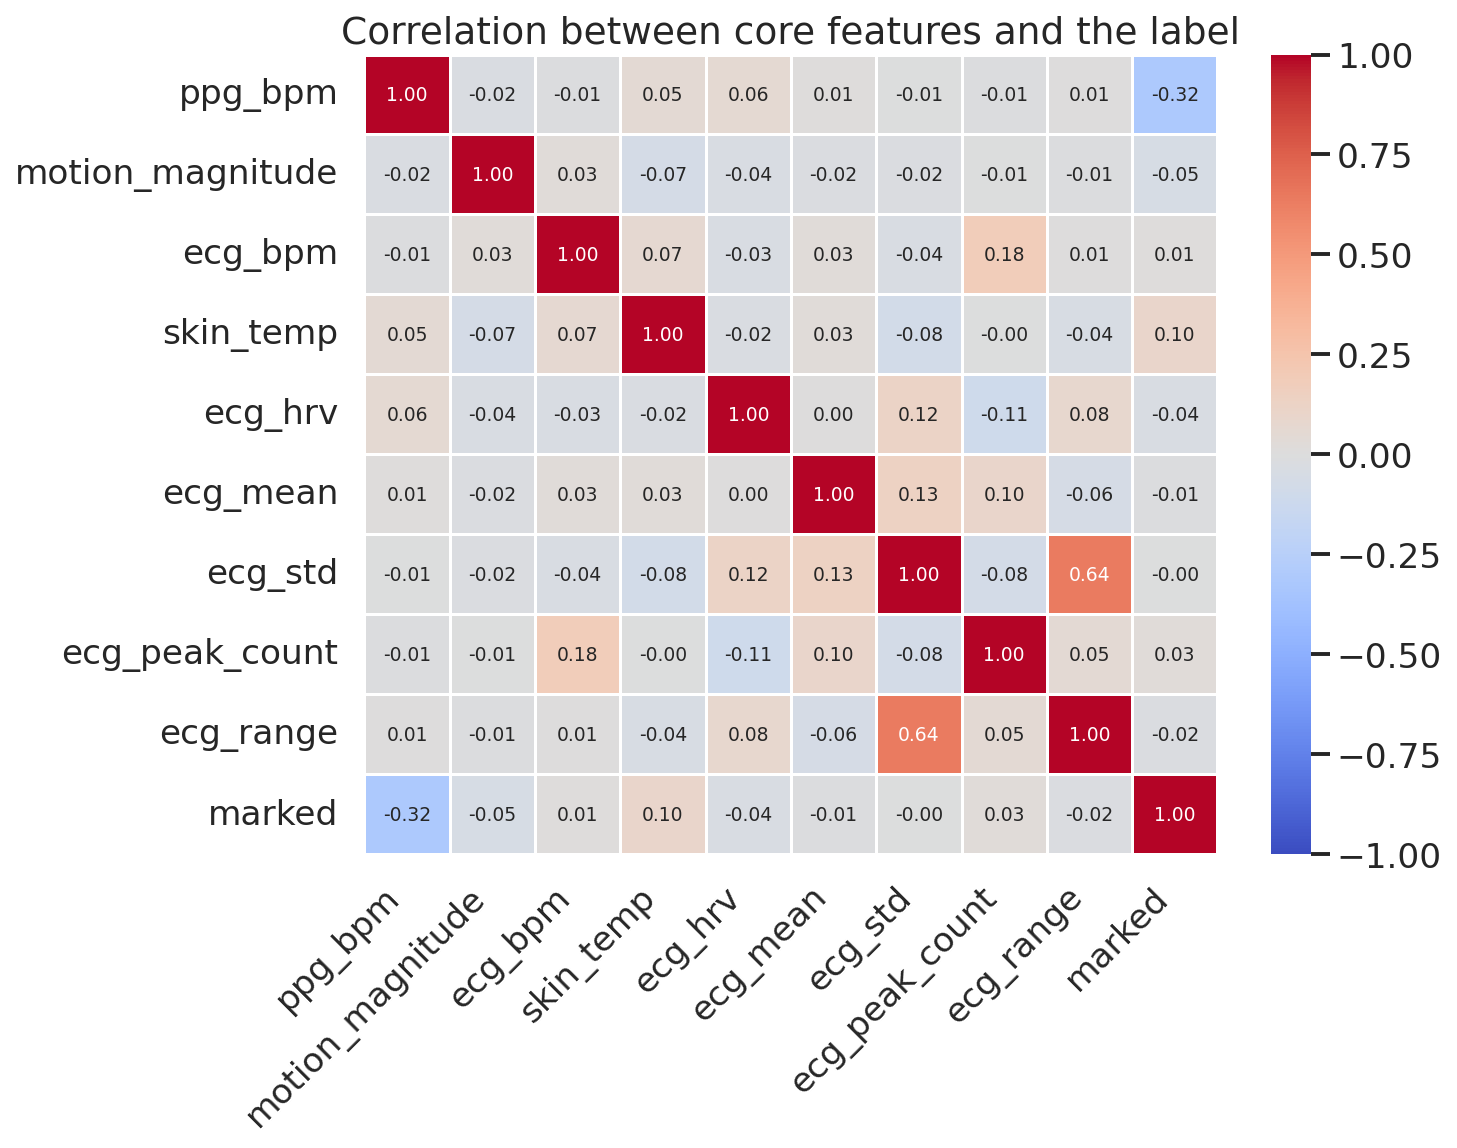

In [ ]:
# correlation heatmap of the core (non-rolling) features, just to sanity-check redundancy
# figsize is sized for a 10x10 grid and annot_kws is set explicitly -- a too-small figure
# for a two-decimal annotation is what causes the numbers to overlap into neighboring cells
core_feats = ["ppg_bpm", "motion_magnitude", "ecg_bpm", "skin_temp", "ecg_hrv",
              "ecg_mean", "ecg_std", "ecg_peak_count", "ecg_range"]
plt.figure(figsize=(10, 8))
sns.heatmap(df[core_feats + ["marked"]].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, annot_kws={"size": 9}, linewidths=0.5, linecolor="white")
plt.title("Correlation between core features and the label")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("fig_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
episode_labels = df.groupby("episode_id")["marked"].first().reset_index()

train_eps, test_eps = train_test_split(
    episode_labels["episode_id"], test_size=0.25,
    stratify=episode_labels["marked"], random_state=RANDOM_STATE)

train_mask = df["episode_id"].isin(train_eps).values
test_mask  = df["episode_id"].isin(test_eps).values

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
groups_train = groups_full[train_mask]

print(f"Train: {X_train.shape[0]} rows, {y_train.sum()} positive "
      f"({y_train.mean()*100:.1f}%), {len(np.unique(groups_train))} episodes")
print(f"Test : {X_test.shape[0]} rows, {y_test.sum()} positive "
      f"({y_test.mean()*100:.1f}%), {test_eps.shape[0]} episodes")

Train: 1624 rows, 107 positive (6.6%), 35 episodes
Test : 380 rows, 82 positive (21.6%), 12 episodes


In [ ]:
models = {
    "LogReg": Pipeline([("sc", StandardScaler()),
                         ("clf", LogisticRegression(max_iter=2000, class_weight="balanced",
                                                     random_state=RANDOM_STATE))]),
    "RandomForest": Pipeline([("sc", StandardScaler()),
                               ("clf", RandomForestClassifier(class_weight="balanced",
                                                                random_state=RANDOM_STATE))]),
    "HistGB": Pipeline([("sc", StandardScaler()),
                         ("clf", HistGradientBoostingClassifier(random_state=RANDOM_STATE))]),
    "SVM": Pipeline([("sc", StandardScaler()),
                      ("clf", SVC(probability=True, class_weight="balanced",
                                  random_state=RANDOM_STATE))]),
}

# deliberately small, shallow-leaning grids: with ~1600 training rows and only 35
# training episodes, a wide/deep search is itself a way to overfit the CV score
param_grids = {
    "LogReg":       {"clf__C": [0.01, 0.1, 1, 10]},
    "RandomForest": {"clf__n_estimators": [200, 400], "clf__max_depth": [3, 5, 8]},
    "HistGB":       {"clf__max_depth": [3, 5], "clf__learning_rate": [0.05, 0.1]},
    "SVM":          {"clf__C": [0.1, 1, 10], "clf__kernel": ["rbf"]},
}

gkf = GroupKFold(n_splits=5)
cv_splits = list(gkf.split(X_train, y_train, groups=groups_train))

fitted = {}
cv_rows = []
for name, pipe in models.items():
    gs = GridSearchCV(pipe, param_grids[name], cv=cv_splits, scoring="f1", n_jobs=-1)
    gs.fit(X_train, y_train)
    fitted[name] = gs
    best_idx = gs.best_index_
    cv_rows.append({
        "model": name,
        "cv_f1_mean": gs.cv_results_["mean_test_score"][best_idx],
        "cv_f1_std":  gs.cv_results_["std_test_score"][best_idx],
        "best_params": gs.best_params_,
    })
    print(f"{name:12s} best grouped-CV F1 = {gs.best_score_:.3f}  params={gs.best_params_}")

cv_table = pd.DataFrame(cv_rows)
cv_table

LogReg       best grouped-CV F1 = 0.367  params={'clf__C': 10}
RandomForest best grouped-CV F1 = 0.454  params={'clf__max_depth': 5, 'clf__n_estimators': 400}
HistGB       best grouped-CV F1 = 0.458  params={'clf__learning_rate': 0.1, 'clf__max_depth': 5}
SVM          best grouped-CV F1 = 0.373  params={'clf__C': 1, 'clf__kernel': 'rbf'}


,model,cv_f1_mean,cv_f1_std,best_params
0,LogReg,0.366854,0.307872,{'clf__C': 10}
1,RandomForest,0.454368,0.374068,"{'clf__max_depth': 5, 'clf__n_estimators': 400}"
2,HistGB,0.457704,0.375761,"{'clf__learning_rate': 0.1, 'clf__max_depth': 5}"
3,SVM,0.373351,0.309215,"{'clf__C': 1, 'clf__kernel': 'rbf'}"


In [ ]:
test_rows = []
proba_by_model = {}
for name, gs in fitted.items():
    pred  = gs.predict(X_test)
    proba = gs.predict_proba(X_test)[:, 1]
    proba_by_model[name] = proba
    report = classification_report(y_test, pred, output_dict=True, zero_division=0)
    test_rows.append({
        "model": name,
        "precision_1": report["1"]["precision"],
        "recall_1":    report["1"]["recall"],
        "f1_1":        report["1"]["f1-score"],
        "accuracy":    report["accuracy"],
        "roc_auc":     roc_auc_score(y_test, proba),
        "pr_auc":      average_precision_score(y_test, proba),
    })

test_table = pd.DataFrame(test_rows).sort_values("f1_1", ascending=False).reset_index(drop=True)
test_table.round(3)

,model,precision_1,recall_1,f1_1,accuracy,roc_auc,pr_auc
0,RandomForest,0.767,0.805,0.786,0.905,0.939,0.737
1,LogReg,0.661,0.902,0.763,0.879,0.957,0.877
2,SVM,0.680,0.622,0.650,0.855,0.879,0.711
3,HistGB,0.647,0.134,0.222,0.797,0.931,0.704


In [ ]:
BEST_MODEL = test_table.iloc[0]["model"]
print("Best model on held-out episodes:", BEST_MODEL)
best_gs = fitted[BEST_MODEL]
best_pred = best_gs.predict(X_test)
best_proba = proba_by_model[BEST_MODEL]
print(classification_report(y_test, best_pred, digits=3, zero_division=0))

Best model on held-out episodes: RandomForest
              precision    recall  f1-score   support

           0      0.946     0.933     0.939       298
           1      0.767     0.805     0.786        82

    accuracy                          0.905       380
   macro avg      0.857     0.869     0.862       380
weighted avg      0.907     0.905     0.906       380



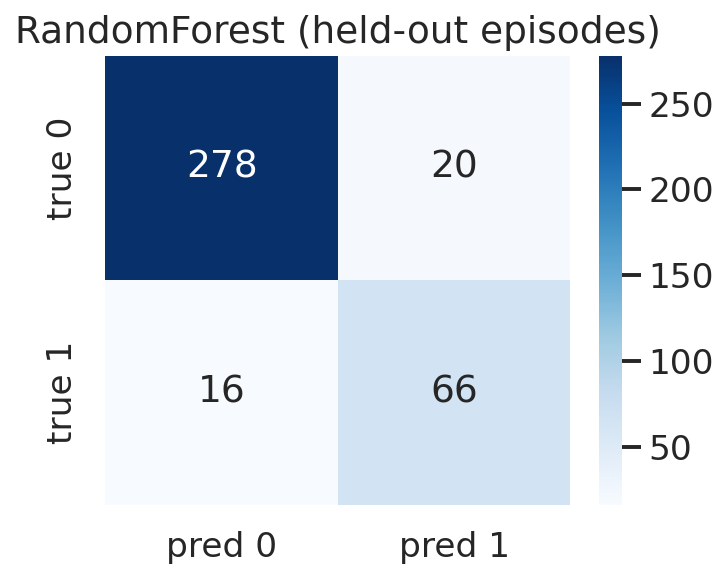

In [ ]:
# --- confusion matrix ---
cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5, 4.2))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["pred 0", "pred 1"], yticklabels=["true 0", "true 1"])
plt.title(f"{BEST_MODEL} (held-out episodes)")
plt.tight_layout()
plt.savefig("fig_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

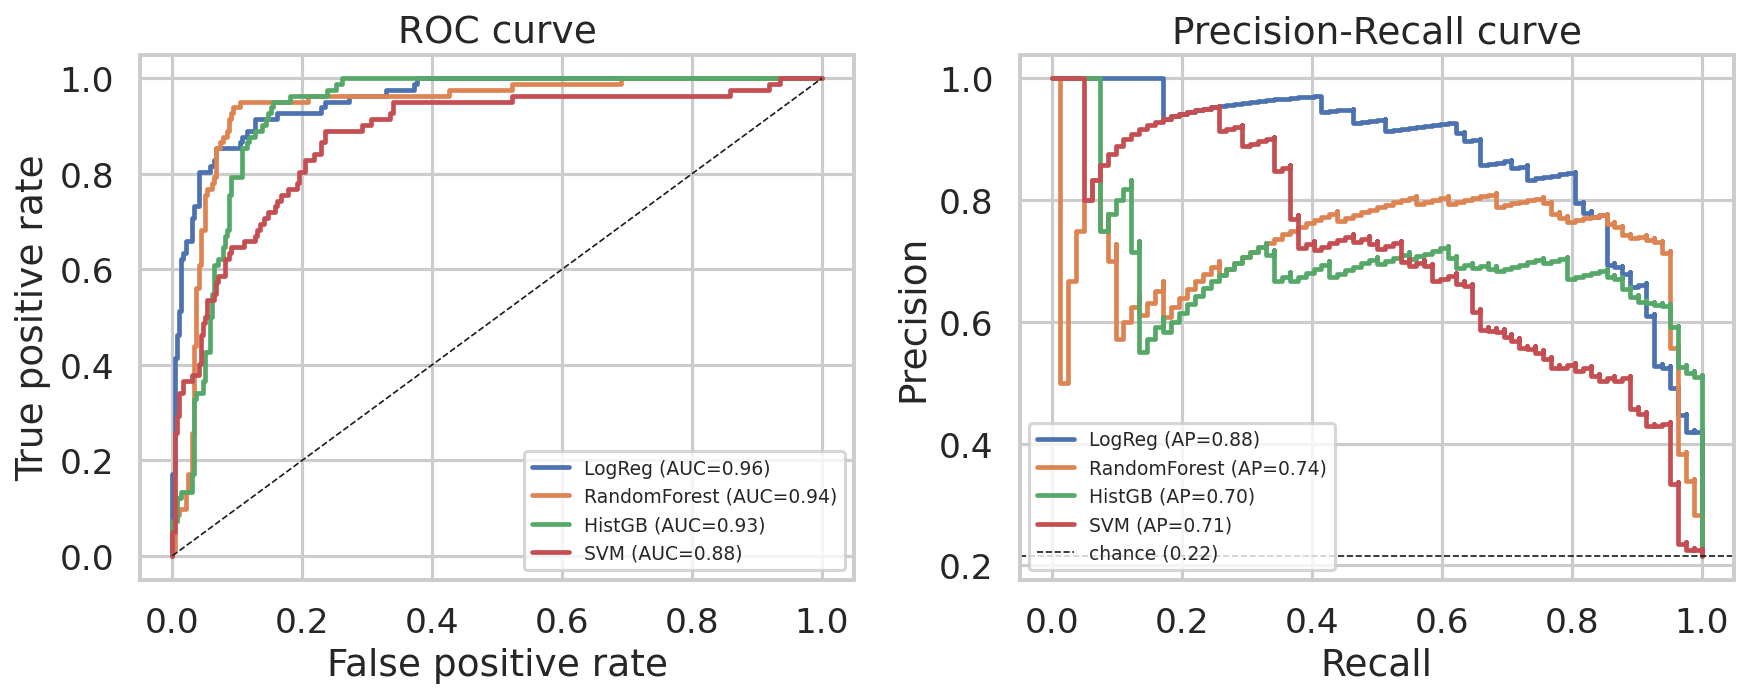

In [ ]:
# --- ROC and Precision-Recall curves, all models overlaid ---
# ROC is drawn with straight segments between operating points (the normal convention).
# The PR curve is drawn with drawstyle="steps-post" instead of a plain line: precision is
# only truly defined AT each recall value produced by the threshold sweep, so connecting
# points with diagonal lines (matplotlib's default) draws precision values that were never
# actually achieved and exaggerates the zig-zag into sharp diagonal spikes. steps-post
# renders the real step function -- same underlying (jagged, small-test-set) data, but it
# reads as the standard PR-curve staircase instead of visual noise.
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for name, proba in proba_by_model.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.2f})")
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ax[1].step(rec[::-1], prec[::-1], where="post",
               label=f"{name} (AP={average_precision_score(y_test, proba):.2f})")

ax[0].plot([0, 1], [0, 1], "k--", lw=0.8)
ax[0].set_xlabel("False positive rate"); ax[0].set_ylabel("True positive rate")
ax[0].set_title("ROC curve"); ax[0].legend(fontsize=9)

base_rate = y_test.mean()
ax[1].axhline(base_rate, color="k", ls="--", lw=0.8, label=f"chance ({base_rate:.2f})")
ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision")
ax[1].set_title("Precision-Recall curve"); ax[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig("fig_roc_pr_curves.png", dpi=300, bbox_inches="tight")
plt.show()


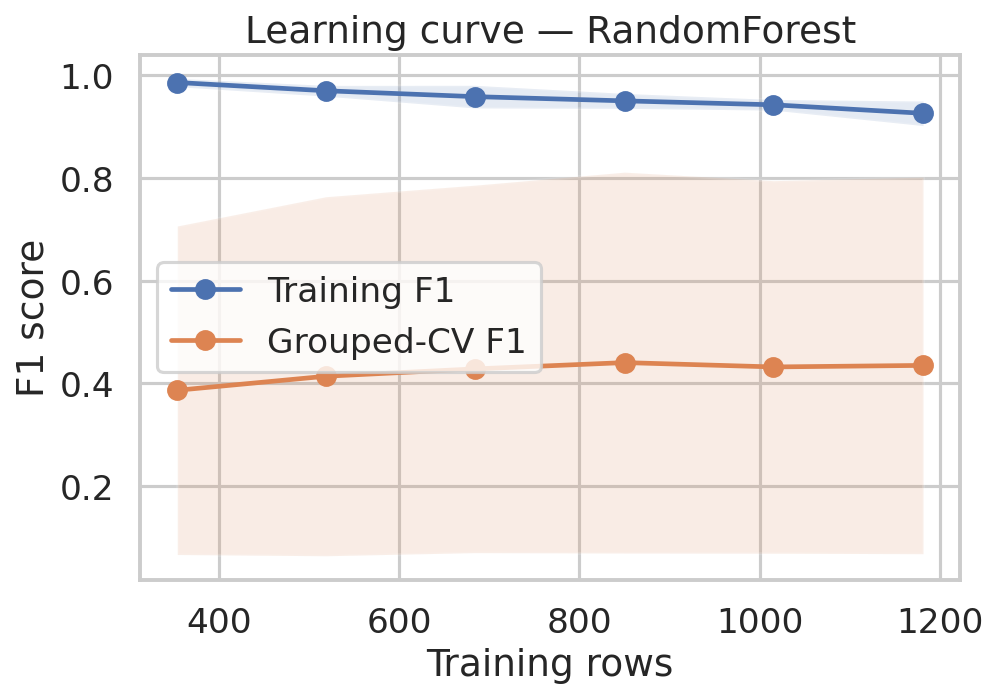

Train-CV F1 gap at full training size: 0.491 (a large positive gap = still overfitting on this small sample)


In [ ]:
best_estimator = best_gs.best_estimator_

train_sizes, train_scores, val_scores = learning_curve(
    best_estimator, X_train, y_train, cv=cv_splits, scoring="f1",
    train_sizes=np.linspace(0.3, 1.0, 6), n_jobs=-1)

plt.figure(figsize=(7, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Training F1")
plt.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                  train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15)
plt.plot(train_sizes, val_scores.mean(axis=1), "o-", label="Grouped-CV F1")
plt.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                  val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15)
plt.xlabel("Training rows"); plt.ylabel("F1 score")
plt.title(f"Learning curve — {BEST_MODEL}")
plt.legend()
plt.tight_layout()
plt.savefig("fig_learning_curve.png", dpi=300, bbox_inches="tight")
plt.show()

gap = train_scores.mean(axis=1)[-1] - val_scores.mean(axis=1)[-1]
print(f"Train-CV F1 gap at full training size: {gap:.3f} "
      "(a large positive gap = still overfitting on this small sample)")

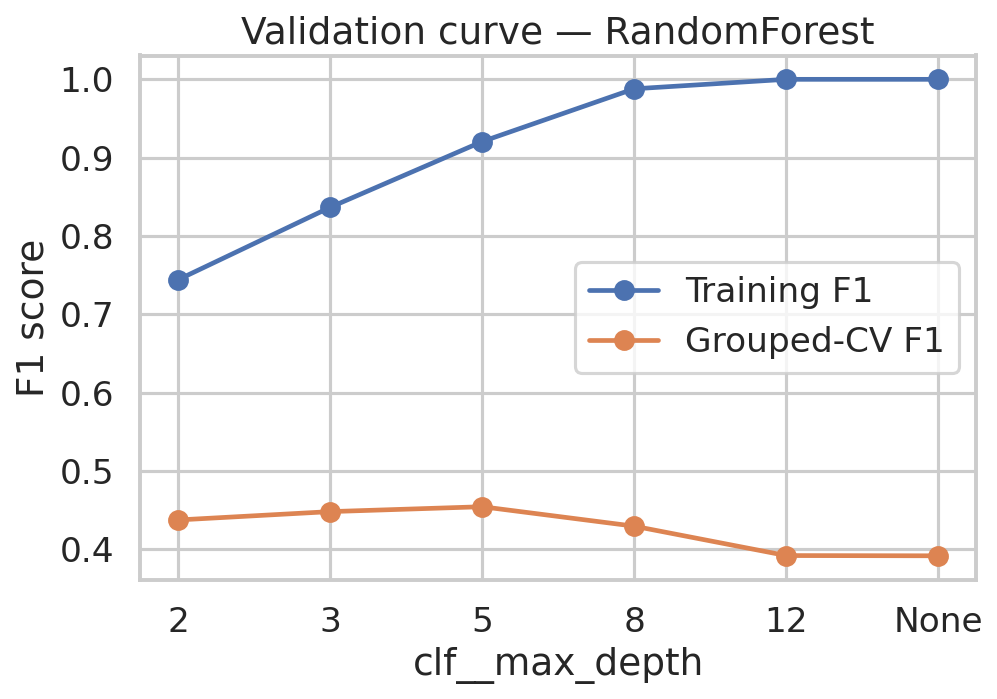

In [ ]:
# validation curve: only meaningful for models with a clear complexity knob.
# Swap 'clf__max_depth' / param_range for whichever hyperparameter matches BEST_MODEL.
complexity_param = {
    "RandomForest": ("clf__max_depth", [2, 3, 5, 8, 12, None]),
    "HistGB":       ("clf__max_depth", [1, 2, 3, 5, 8]),
    "LogReg":       ("clf__C", [0.001, 0.01, 0.1, 1, 10, 100]),
    "SVM":          ("clf__C", [0.01, 0.1, 1, 10, 100]),
}
param_name, param_range = complexity_param[BEST_MODEL]

train_sc, val_sc = validation_curve(
    best_estimator, X_train, y_train, param_name=param_name, param_range=param_range,
    cv=cv_splits, scoring="f1", n_jobs=-1)

x_labels = [str(p) for p in param_range]
plt.figure(figsize=(7, 5))
plt.plot(x_labels, train_sc.mean(axis=1), "o-", label="Training F1")
plt.plot(x_labels, val_sc.mean(axis=1), "o-", label="Grouped-CV F1")
plt.xlabel(param_name); plt.ylabel("F1 score")
plt.title(f"Validation curve — {BEST_MODEL}")
plt.legend()
plt.tight_layout()
plt.savefig("fig_validation_curve.png", dpi=300, bbox_inches="tight")
plt.show()

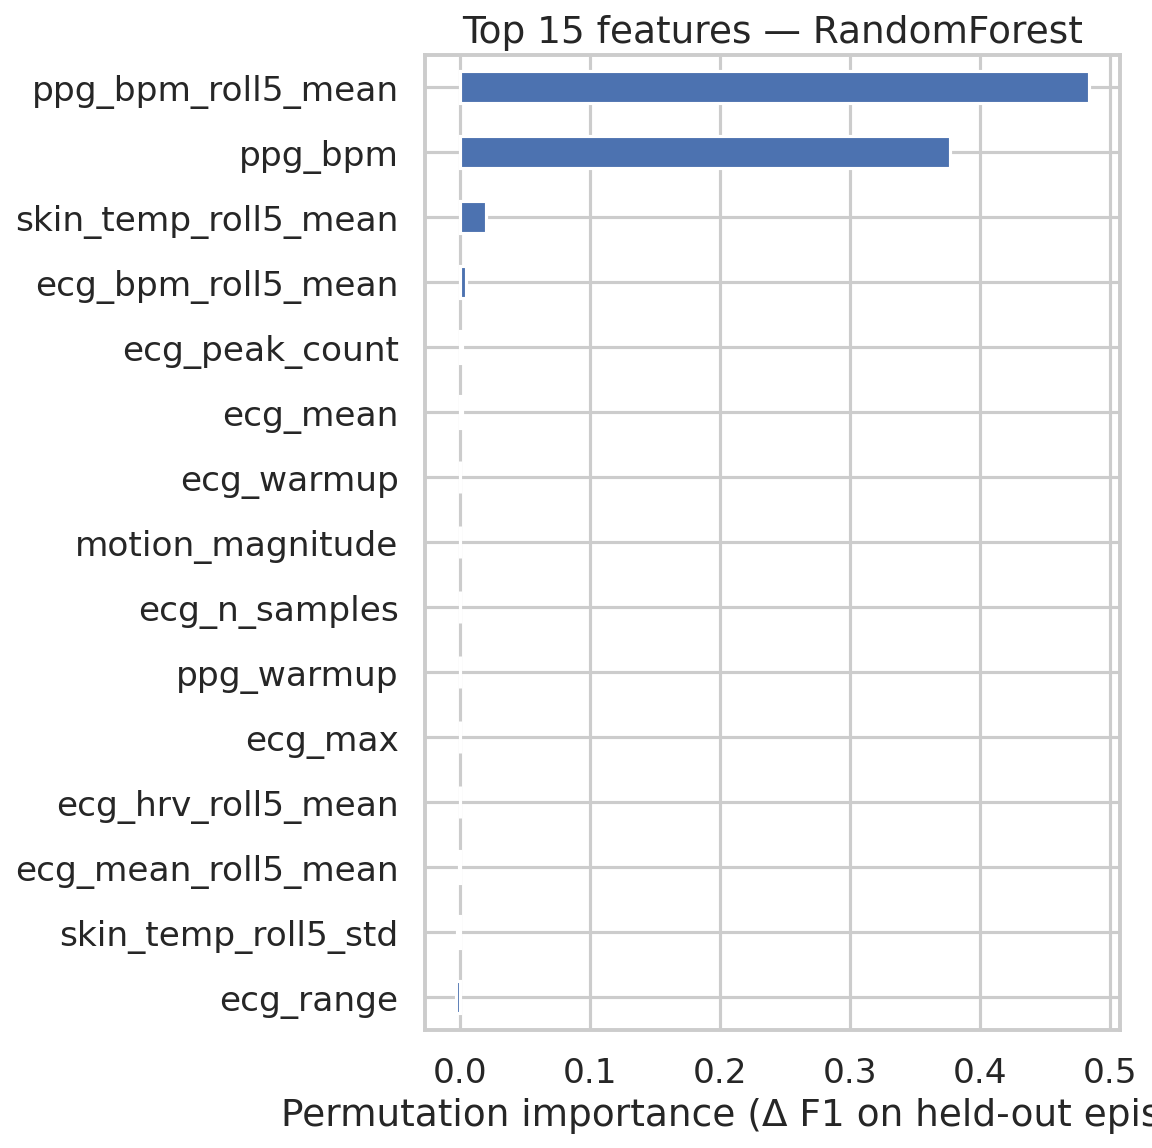

,0
ppg_bpm_roll5_mean,0.483429
ppg_bpm,0.376580
skin_temp_roll5_mean,0.019547
ecg_bpm_roll5_mean,0.004608
ecg_peak_count,0.001454
ecg_mean,0.001212
ecg_max,0.000000
ppg_warmup,0.000000
ecg_warmup,0.000000
ecg_n_samples,0.000000


In [ ]:
perm = permutation_importance(best_estimator, X_test, y_test, scoring="f1",
                               n_repeats=30, random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
imp.head(15).sort_values().plot(kind="barh", color="#4C72B0")
plt.xlabel("Permutation importance (Δ F1 on held-out episodes)")
plt.title(f"Top 15 features — {BEST_MODEL}")
plt.tight_layout()
plt.savefig("fig_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()
imp.head(15)

In [ ]:
cv_table_out = cv_table.drop(columns="best_params").round(3)
test_table_out = test_table.round(3)

cv_table_out.to_csv("table_cv_results.csv", index=False)
test_table_out.to_csv("table_test_results.csv", index=False)

with open("table_cv_results.tex", "w") as f:
    f.write(cv_table_out.to_latex(index=False,
             caption="Grouped 5-fold cross-validation F1 (mean, std) per model.",
             label="tab:cv_results"))

with open("table_test_results.tex", "w") as f:
    f.write(test_table_out.to_latex(index=False,
             caption="Held-out (unseen episode) test performance per model.",
             label="tab:test_results"))

print("Saved: table_cv_results.csv/.tex, table_test_results.csv/.tex")
print("Saved figures: fig_class_balance.png, fig_session_timeline.png, fig_correlation.png,")
print("               fig_confusion_matrix.png, fig_roc_pr_curves.png, fig_learning_curve.png,")
print("               fig_validation_curve.png, fig_feature_importance.png")
cv_table_out

Saved: table_cv_results.csv/.tex, table_test_results.csv/.tex
Saved figures: fig_class_balance.png, fig_session_timeline.png, fig_correlation.png,
               fig_confusion_matrix.png, fig_roc_pr_curves.png, fig_learning_curve.png,
               fig_validation_curve.png, fig_feature_importance.png


,model,cv_f1_mean,cv_f1_std
0,LogReg,0.367,0.308
1,RandomForest,0.454,0.374
2,HistGB,0.458,0.376
3,SVM,0.373,0.309


In [ ]:
test_table_out

,model,precision_1,recall_1,f1_1,accuracy,roc_auc,pr_auc
0,RandomForest,0.767,0.805,0.786,0.905,0.939,0.737
1,LogReg,0.661,0.902,0.763,0.879,0.957,0.877
2,SVM,0.680,0.622,0.650,0.855,0.879,0.711
3,HistGB,0.647,0.134,0.222,0.797,0.931,0.704


In [ ]:
SESSION_MIN = (summ["timestamp"].max()-summ["timestamp"].min()).total_seconds()/60
N_ROWS      = len(df)
ECG_HZ      = len(ecg)/((ecg["timestamp"].max()-ecg["timestamp"].min()).total_seconds())
N_EPISODES  = df["episode_id"].nunique()
N_POS_EP    = int((episode_labels["marked"]==1).sum())
N_NEG_EP    = int((episode_labels["marked"]==0).sum())
POS_PCT     = df["marked"].mean()*100
BEST_F1     = test_table_out.iloc[0]["f1_1"]
BEST_AUC    = test_table_out.iloc[0]["roc_auc"]
BEST_PRAUC  = test_table_out.iloc[0]["pr_auc"]

summary_text = (
    f"SESSION_MIN = {SESSION_MIN:.1f}\n"
    f"N_ROWS      = {N_ROWS}\n"
    f"ECG_HZ      = {ECG_HZ:.1f}\n"
    f"N_EPISODES  = {N_EPISODES}\n"
    f"N_POS_EP    = {N_POS_EP}\n"
    f"N_NEG_EP    = {N_NEG_EP}\n"
    f"POS_PCT     = {POS_PCT:.1f}\n"
    f"BEST_MODEL  = {BEST_MODEL}\n"
    f"BEST_F1     = {BEST_F1:.2f}\n"
    f"BEST_AUC    = {BEST_AUC:.2f}\n"
    f"BEST_PRAUC  = {BEST_PRAUC:.2f}\n"
    f"GAP         = {gap:.2f}\n"
)
print(summary_text)

SESSION_MIN = 35.2
N_ROWS      = 2004
ECG_HZ      = 43.3
N_EPISODES  = 47
N_POS_EP    = 23
N_NEG_EP    = 24
POS_PCT     = 9.4
BEST_MODEL  = RandomForest
BEST_F1     = 0.79
BEST_AUC    = 0.94
BEST_PRAUC  = 0.74
GAP         = 0.49

